# Implementing Reinforcement Learnig Algorithms in Games

### Setup

In [1]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import tqdm
import random
from collections import deque

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

import stable_retro
import gymnasium as gym
from shimmy.openai_gym_compatibility import GymV21CompatibilityV0

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

print(f"Using {device} device")

Using cuda device


### Run the Agent

In [18]:
import gymnasium as gym
import numpy as np
import stable_retro as retro
import cv2
import time
import matplotlib.pyplot as plt
import argparse

class AirStrikerActionWrapper(gym.ActionWrapper):
    """This class will simplify the action space available to the agent into a discrete space that is mapped to the button inputs on a Genesis controller.
       Normally there are many different possible action inputs that make the state-action space much more complex."""
    
    # each sub-list gives the button indices to press at the same time: (index 0 = B/shoot, 4 = up, etc.)
    DEFAULT_COMBOS = [
        [],          # 0  NOOP
        [0],         # 1  B  (shoot)
        [4],         # 2  UP
        [5],         # 3  DOWN
        [6],         # 4  LEFT
        [7],         # 5  RIGHT
        [4, 0],      # 6  UP    + SHOOT
        [5, 0],      # 7  DOWN  + SHOOT
        [6, 0],      # 8  LEFT  + SHOOT
        [7, 0],      # 9  RIGHT + SHOOT
    ]
 
    def __init__(self, env, combos=None):
        """Takes in an already created env object as parameter, as well as an optional action space"""
        super().__init__(env)
        self.combos = combos if combos is not None else self.DEFAULT_COMBOS
        self.n_buttons = env.action_space.n  # number of total possible acitons
        self.action_space = gym.spaces.Discrete(len(self.combos))
 
    def action(self, act_index: int):
        """Convert a discrete action index to the action array accepted by the env (e.g. [1, 0, 0, 1, 0, ..., 0])"""
        multi = np.zeros(self.n_buttons, dtype=np.int8)
        for btn in self.combos[act_index]:
            multi[btn] = 1
        return multi

class ClipReward(gym.RewardWrapper):
    """This class will clip the rewards to within a range of [-1, 1] instead of having potentially very large values"""
    def __init__(self, env):
        super().__init__(env)

    def reward(self, reward):
        # np.sign returns -1 for negative, 0 for zero, 1 for positive
        return np.sign(reward)

class GrayscaleWrapper(gym.ObservationWrapper):
    """ A wrapper for the observations of frames obtained from the game that applies grayscale
        # to remove high dimensionality of using colors in the frame images"""
    def __init__(self, env):
        super().__init__(env)
        obs_shape = self.observation_space.shape[:2]  # (H, W)
        self.observation_space = gym.spaces.Box(
            low=0, high=255, shape=(*obs_shape, 1), dtype=np.uint8
        )
    
    def observation(self, obs):
        """Return the given observation in grayscale with format: grayscale uint8 (H, W, 1)"""
        gray = cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)
        return gray[:, :, np.newaxis]

class ResizeWrapper(gym.ObservationWrapper):
    """Wrapper to resize the game screen dimensions (normally 224 x 320) to a smaller square (e.g. 84 x 84)"""
    def __init__(self, env, size=84):
        super().__init__(env)
        self.size = size
        self.observation_space = gym.spaces.Box(
            low=0, high=255, shape=(size, size, 1), dtype=np.uint8
        )
 
    def observation(self, obs):
        """obs is (H, W, 1) — squeeze channel for cv2, then add it back"""
        resized = cv2.resize(
            obs[:, :, 0], (self.size, self.size), interpolation=cv2.INTER_AREA
        )
        return resized[:, :, np.newaxis]

class FrameStackWrapper(gym.Wrapper):
    """Class that handles stacking frames together to capture velocity of player ship and enemy objects over some bit of time"""
    def __init__(self, env, num_frames=4):
        super().__init__(env)
        self.k = num_frames
        self._frames = np.zeros(
            (num_frames, *env.observation_space.shape[:2]), dtype=np.uint8
        )
        h, w = env.observation_space.shape[:2]
        self.observation_space = gym.spaces.Box(
            low=0, high=255, shape=(num_frames, h, w), dtype=np.uint8
        )
    
    def reset(self, **kwargs):
        """Resets the framestack"""
        obs, info = self.env.reset(**kwargs)
        frame = obs[:, :, 0]  # (H, W)
        for i in range(self.k):
            self._frames[i] = frame
        return self._frames.copy(), info
 
    def step(self, action):
        """advance the frame by one. Returns the new stack of frames after the step + reward, terminated, truc, info"""
        obs, reward, terminated, truncated, info = self.env.step(action)
        frame = obs[:, :, 0]

        # shift frames left and insert the new one at the end
        self._frames[:-1] = self._frames[1:]
        self._frames[-1] = frame
        return self._frames.copy(), reward, terminated, truncated, info

debug_flag = False

# create the environment for the agent to play the game in, with wrappers applied
def create_airstriker_env(game="Airstriker-Genesis-v0", state=retro.State.DEFAULT, frame_stack=4, resize=84, clip_rewards=True,render_mode: str | None = None,
):
    """
    Creates and wraps a stable-retro environment
 
    Returns an env with:
      - observation space = (frame_stack, resize, resize) uint8 <- FrameStackWrapper() + ResizeWrapper()
      - action space is Discrete(10) <- AirStrikerActionWrapper()
      - rewards are clipped to [-1, 1] <- ClipReward()
 
    Parameters:
    ----------
    game : str
        ROM name supported by stable-retor (i.e. "Airstriker-Genesis-v0")
    state : str
        Initial save-state to load
    frame_stack : int
        Number of consecutive frames to stack (using FrameStackWrapper)
    resize : int
        Spatial size to resize frames to (square) (using ResizeWrapper)
    clip_rewards : bool
        Whether or not to clip rewards to {-1, 0, +1} (using ClipReward)
    render_mode : str or None
        Set to "human" to open a UI window, None otherwise
    """
    try:
        env.close()
    except NameError:
        env = retro.make(game=game, state=state, render_mode=render_mode)
    env = AirStrikerActionWrapper(env)
    env = GrayscaleWrapper(env)
    env = ResizeWrapper(env, size=resize)
    if clip_rewards:
        env = ClipReward(env)
    env = FrameStackWrapper(env, num_frames=frame_stack)
    return env

def run_random_steps(total_steps: int = 1_000_000, render: bool = False, log_every: int = 10_000):
    render_mode = "human" if render else None
    env = create_airstriker_env(render_mode=render_mode)
 
    print("=" * 70)
    print("STATS")
    print("=" * 70)
    print(f"Game: Airstriker-Genesis-v0")
    print(f"Observation space: {env.observation_space}")
    print(f"Obs dtype: {env.observation_space.dtype}")
    print(f"Action space: {env.action_space}  (n={env.action_space.n})")
    print(f"Total steps: {total_steps}")
    print(f"Log every: {log_every} steps")
    print("=" * 70)
 
    all_ep_rewards = []
    cumulative_reward = 0.0
    ep_reward = 0.0
    ep_count = 0
    last_log_episodes = 0  # episodes at last log point
    start_time = time.time()
 
    # finer reward tracking
    cumulative_rewards = []  # cumulative_rewards[t] = total reward collected through step t
    average_rewards = []     # average_rewards[t]    = cumulative_rewards[t] / (t + 1)
    step_reward_sum = 0.0    # running sum of per-step rewards
 
    obs, info = env.reset()
    assert obs.shape == env.observation_space.shape, (
        f"Shape mismatch: got {obs.shape}, expected {env.observation_space.shape}"
    )
    assert obs.dtype == np.uint8, f"Dtype mismatch: got {obs.dtype}"
 
    for step in range(1, total_steps + 1):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        ep_reward += reward
        done = terminated or truncated
 
        # track per-step rewards
        step_reward_sum += reward
        cumulative_rewards.append(step_reward_sum)
        average_rewards.append(step_reward_sum / step)
 
        if render:
            time.sleep(0.01)
 
        if done:
            ep_count += 1
            all_ep_rewards.append(ep_reward)
            cumulative_reward += ep_reward
            ep_reward = 0.0
            obs, info = env.reset()
 
        if step % log_every == 0:
            elapsed = time.time() - start_time
            fps = step / elapsed
            new_eps = ep_count - last_log_episodes
            last_log_episodes = ep_count
 
            if all_ep_rewards:
                recent = all_ep_rewards[-new_eps:] if new_eps > 0 else all_ep_rewards[-1:]
                recent_mean = np.mean(recent)
                overall_mean = np.mean(all_ep_rewards)
            else:
                recent_mean = 0.0
                overall_mean = 0.0
 
            print(
                f"  Step {step}/{total_steps} | "
                f"Episodes: {ep_count} | "
                f"Recent mean: {recent_mean} | "
                f"Overall mean: {overall_mean} | "
                f"Cumulative: {cumulative_reward} | "
                f"FPS: {fps}"
            )
 
    env.close()
 
    elapsed = time.time() - start_time

    print("-" * 70)
    print(f"Completed {total_steps} steps in {elapsed}s ({total_steps / elapsed} FPS)")
    print(f"Total episodes: {ep_count}")
    print(f"Total cumulative reward: {cumulative_reward}")
 
    return cumulative_rewards, average_rewards

cumulative_rewards, average_rewards = run_random_steps()

STATS
Game: Airstriker-Genesis-v0
Observation space: Box(0, 255, (4, 84, 84), uint8)
Obs dtype: uint8
Action space: Discrete(10)  (n=10)
Total steps: 1000000
Log every: 10000 steps
  Step 10000/1000000 | Episodes: 7 | Recent mean: 0.14285714285714285 | Overall mean: 0.14285714285714285 | Cumulative: 1.0 | FPS: 2075.9554568082594
  Step 20000/1000000 | Episodes: 14 | Recent mean: 0.42857142857142855 | Overall mean: 0.2857142857142857 | Cumulative: 4.0 | FPS: 2047.058732808259
  Step 30000/1000000 | Episodes: 21 | Recent mean: 0.5714285714285714 | Overall mean: 0.38095238095238093 | Cumulative: 8.0 | FPS: 1979.9651864832467
  Step 40000/1000000 | Episodes: 29 | Recent mean: 0.375 | Overall mean: 0.3793103448275862 | Cumulative: 11.0 | FPS: 1991.9881480071476
  Step 50000/1000000 | Episodes: 36 | Recent mean: 0.5714285714285714 | Overall mean: 0.4166666666666667 | Cumulative: 15.0 | FPS: 2007.3021450350152
  Step 60000/1000000 | Episodes: 44 | Recent mean: 0.0 | Overall mean: 0.3409090909

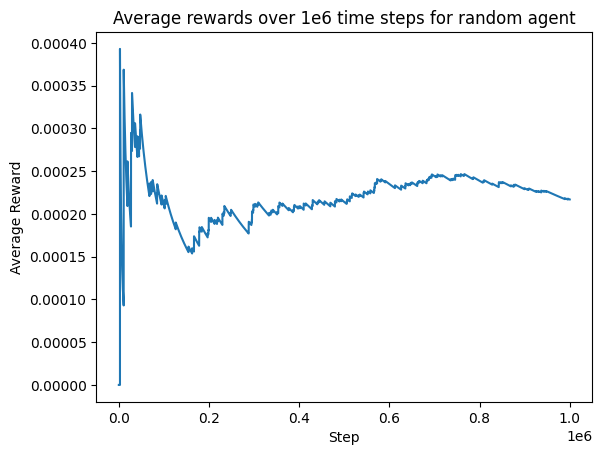

In [19]:
plt.plot(average_rewards)
plt.title("Average rewards over 1e6 time steps for random agent")
plt.xlabel("Step")
plt.ylabel("Average Reward")
plt.show()

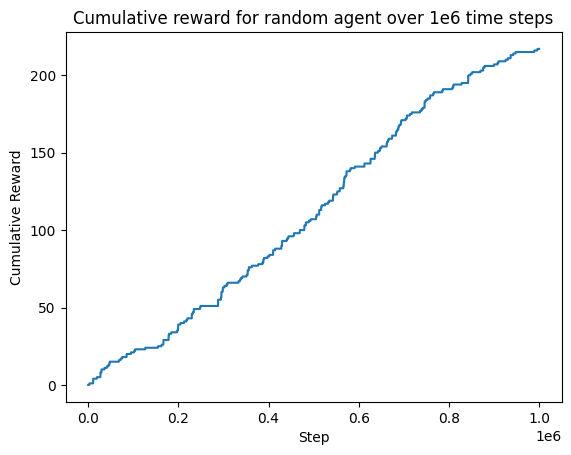

In [20]:
plt.plot(cumulative_rewards)
plt.title("Cumulative reward for random agent over 1e6 time steps")
plt.xlabel("Step")
plt.ylabel("Cumulative Reward")
plt.show()